In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("daily_energy.csv")

In [3]:
df["date"] = pd.to_datetime(df["date"])

df = df.set_index("date")

df = df.sort_index()

df.head()

,kwh
date,
2023-01-01,185.2
2023-01-02,202.8
2023-01-03,164.1
2023-01-04,202.9
2023-01-05,201.2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 726 entries, 2023-01-01 to 2024-12-30
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   kwh     726 non-null    float64
dtypes: float64(1)
memory usage: 11.3 KB


In [5]:
print("Start:", df.index.min())
print("End:", df.index.max())

Start: 2023-01-01 00:00:00
End: 2024-12-30 00:00:00


In [6]:
print("Number of rows:", len(df))

Number of rows: 726


In [7]:
print("Rows before resampling:", len(df))

df = df.resample("D").asfreq()

print("Rows after resampling:", len(df))

print("\nMissing values:")

print(df.isna().sum())

Rows before resampling: 726
Rows after resampling: 730

Missing values:
kwh    4
dtype: int64


In [8]:
df["kwh"] = df["kwh"].interpolate()

df.isna().sum()

,0
kwh,0


First I converted the date column to datetime and set it as the index and sorted the data by date

Then I resampled the data daily to check for missing days. Missing values were handled using linear interpolation because the data is a daily time series and the missing values can be estimated from nearby days

In [9]:
df["rolling_mean"] = df["kwh"].rolling(window=7).mean()

df.head(10)

,kwh,rolling_mean
date,,
2023-01-01,185.2,NaN
2023-01-02,202.8,NaN
2023-01-03,164.1,NaN
2023-01-04,202.9,NaN
2023-01-05,201.2,NaN
2023-01-06,163.6,NaN
2023-01-07,174.5,184.900000
2023-01-08,170.9,182.857143
2023-01-09,183.1,180.042857


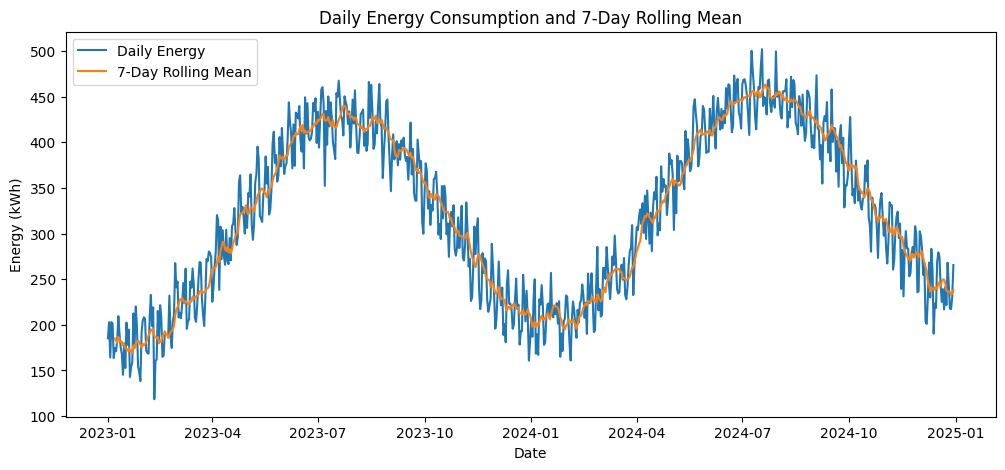

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(df.index, df["kwh"], label="Daily Energy")
plt.plot(df.index, df["rolling_mean"], label="7-Day Rolling Mean")

plt.xlabel("Date")
plt.ylabel("Energy (kWh)")
plt.title("Daily Energy Consumption and 7-Day Rolling Mean")
plt.legend()

plt.show()

The daily energy values fluctuate over time, while the 7-day rolling mean makes the overall trend easier to see

In [11]:
monthly = df.groupby(df.index.month)["kwh"].mean()

monthly

,kwh
date,
1,193.551613
2,206.408772
3,246.603226
4,312.445000
5,371.135484
6,420.941667
7,441.112097
8,427.964516
9,387.795000


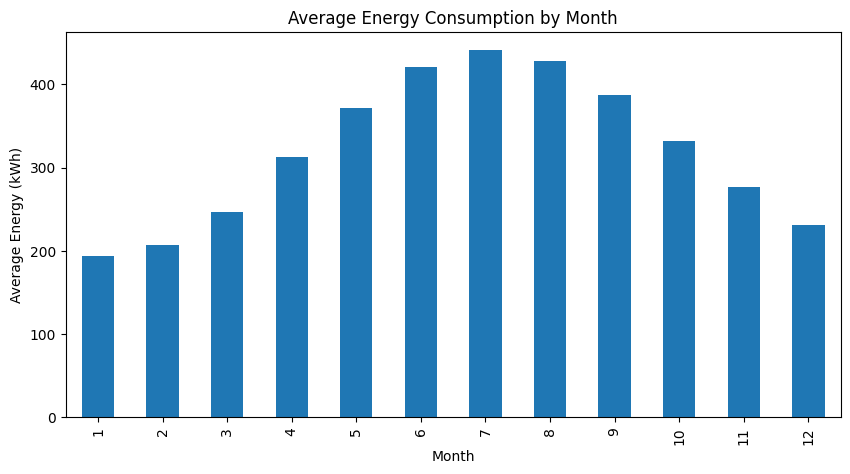

In [12]:
monthly.plot(kind="bar", figsize=(10, 5))

plt.xlabel("Month")
plt.ylabel("Average Energy (kWh)")
plt.title("Average Energy Consumption by Month")

plt.show()

The monthly averages show a clear seasonal pattern energy consumption increases from January and reaches its highest level around July then decreases toward the end of the year

In [13]:
days = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday = df.groupby(df.index.day_name())["kwh"].mean()
weekday = weekday.reindex(days)

weekday

,kwh
date,
Monday,334.240000
Tuesday,336.632692
Wednesday,337.768269
Thursday,336.637019
Friday,300.118269
Saturday,300.831731
Sunday,301.700000


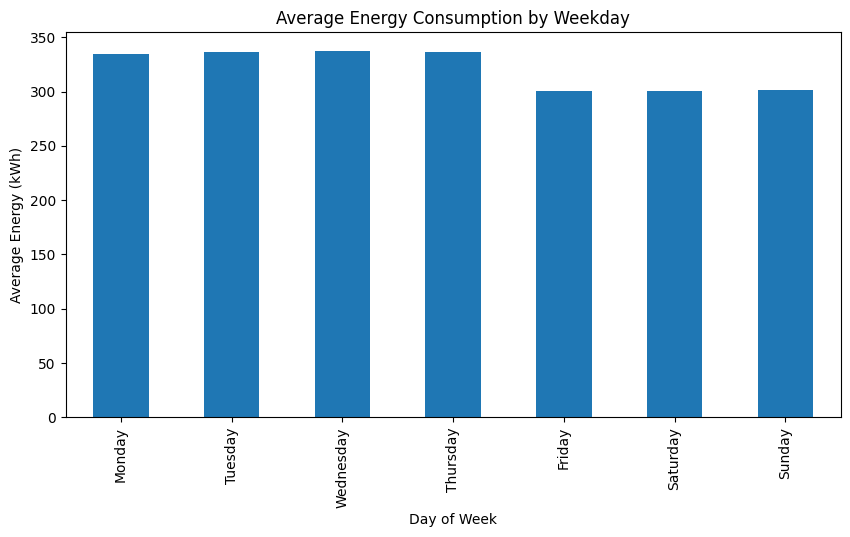

In [14]:
weekday.plot(kind="bar", figsize=(10, 5))

plt.xlabel("Day of Week")
plt.ylabel("Average Energy (kWh)")
plt.title("Average Energy Consumption by Weekday")

plt.show()

The weekday averages show a weekly pattern energy consumption is generally higher from Monday to Thursday and lower during the weekend and it's also closer from each other

------

1.The 7-day rolling mean shows that energy consumption changes over time with higher values around the middle of the year

2.The monthly averages show clear seasonality with energy consumption increasing from January to July and then decreasing toward December

3.Energy consumption is generally higher on weekdays than on weekends showing a weekly seasonal pattern

------

In [15]:
trips = pd.read_csv("trips_large.csv")

trips.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   trip_id          500000 non-null  int64  
 1   zone             500000 non-null  object 
 2   payment_type     500000 non-null  object 
 3   passenger_count  500000 non-null  int64  
 4   trip_distance    500000 non-null  float64
 5   fare_amount      500000 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 66.7 MB


In [16]:
memory_before = trips.memory_usage(deep=True).sum() / 1024**2

print(f"Memory before optimization: {memory_before:.2f} MB")

Memory before optimization: 66.74 MB


In [17]:
trips["trip_id"] = pd.to_numeric(trips["trip_id"], downcast="integer")

trips["passenger_count"] = pd.to_numeric(
    trips["passenger_count"],
    downcast="integer"
)

trips["trip_distance"] = pd.to_numeric(
    trips["trip_distance"],
    downcast="float"
)

trips["fare_amount"] = pd.to_numeric(
    trips["fare_amount"],
    downcast="float"
)

In [18]:
trips["zone"] = trips["zone"].astype("category")

trips["payment_type"] = trips["payment_type"].astype("category")

In [19]:
trips.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype   
---  ------           --------------   -----   
 0   trip_id          500000 non-null  int32   
 1   zone             500000 non-null  category
 2   payment_type     500000 non-null  category
 3   passenger_count  500000 non-null  int8    
 4   trip_distance    500000 non-null  float32 
 5   fare_amount      500000 non-null  float32 
dtypes: category(2), float32(2), int32(1), int8(1)
memory usage: 7.2 MB


I reduced memory usage by downcasting numeric columns and converting low-cardinality text columns to category and this reduced the amount of memory needed to store the dataset

In [20]:
memory_after = trips.memory_usage(deep=True).sum() / 1024**2

print(f"Memory before optimization: {memory_before:.2f} MB")
print(f"Memory after optimization: {memory_after:.2f} MB")

Memory before optimization: 66.74 MB
Memory after optimization: 7.15 MB


Memory usage decreased from 66.74 MB to 7.15 MB after optimizing the data types

In [21]:
import time

In [22]:
start = time.time()

total_sum = 0
total_count = 0

for chunk in pd.read_csv("trips_large.csv", chunksize=10000):
    total_sum += chunk["fare_amount"].sum()
    total_count += chunk["fare_amount"].count()

overall_mean = total_sum / total_count

elapsed_time = time.time() - start

print(f"Overall mean fare: {overall_mean:.2f}")
print(f"Time taken: {elapsed_time:.4f} seconds")

Overall mean fare: 23.01
Time taken: 0.3368 seconds


I calculated the overall mean fare using chunks of 10,000 rows and the sum and count from each chunk were combined to calculate the final mean
The calculation took 0.3368 seconds

In [23]:
trips.to_parquet("trips_optimized.parquet")

In [24]:
import os

In [25]:
csv_size = os.path.getsize("trips_large.csv") / 1024**2
parquet_size = os.path.getsize("trips_optimized.parquet") / 1024**2

print(f"CSV file size: {csv_size:.2f} MB")
print(f"Parquet file size: {parquet_size:.2f} MB")

CSV file size: 15.06 MB
Parquet file size: 4.55 MB


The Parquet file is smaller than the CSV file and The CSV file is 15.06 MB, while the Parquet file is 4.55 MB

------

I would use cloud or distributed tools when the dataset becomes too large to process efficiently on one computer